# Leaf segmentation models experiment

| § | Model | Source | Zero-shot? |
|---|-------|--------|-----------|
| 1 | **SAM 2** | `models/01_sam2/run_sam2.py` | no training required |
| 2 | **Leaf Only SAM** | `models/02_leaf_only_sam/run_leaf_only_sam.py` | no training required |
| 3 | **HQ-SAM** | `models/03_hq_sam/run_hq_sam.py` | no training required |
| 4 | **Mask R-CNN** | `models/04_mask_rcnn/{train,run}_mask_rcnn.py` | needs fine-tune |
| 5 | **YOLO11-seg** | `models/05_yolo_seg/{masks_to_yolo,train_yolo_seg,run_yolo_seg}.py` | needs fine-tune |
| 6 | **Mask2Former** | `models/06_mask2former/run_mask2former.py` | no training required - COCO baseline |

# 1. Initial Setup

This section defines the common functions necessary for processing of pretrained model and finetune models.

In [1]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import glob
import os
import shutil

import cv2
import csv

import pandas as pd

from ultralytics import YOLO
import torch

### Data loader functions

Images and their corresponding labels (masked images) are loaded from the specified directory. Each image is resized to w × h (224 × 224), which limits memory usage and helps avoid out-of-memory errors while preserving sufficient detail

In [2]:
w = 224
h = 224

def load_image(path: str) -> np.ndarray:
    """Load an image file as a (h, w, 3) uint8 RGB array, resized to h x w."""
    image = Image.open(path).convert("RGB").resize((w, h), Image.LANCZOS)
    return np.array(image)


def load_label_image(path: str) -> np.ndarray:
    """Load a per-leaf label map as an (h, w) array, resized like `load_image`."""
    return np.array(Image.open(path).resize((w, h), Image.LANCZOS))

def get_masks_from_label_image(label_image: np.ndarray) -> List[np.ndarray]:
    """Split a semantic/instance label image into a list of boolean masks (skip 0 - background)."""
    return [label_image == v for v in np.unique(label_image) if v != 0]

### Overlay mask function

Draw the masks on top of the original image. Used for checking the output of segmentation model

In [3]:
import colorsys

def overlay_masks(
    image: np.ndarray,
    masks: Sequence[np.ndarray],
    alpha: float = 0.5, # control the color transparency of the masks
    draw_contours: bool = True, # If true, the edges of the masks's boundaries will be clearer
    seed: int = 0, # random seed of colors
) -> np.ndarray:
    """Blend a list of boolean instance masks onto `image` with distinct colors."""

    def _distinct_colors(n: int) -> np.ndarray:
        """An (n, 3) uint8 array of visually distinct colors."""
        rng = np.random.default_rng(seed)
        n = max(int(n), 1)
        hsv = [((i / n + rng.uniform(0, 0.08)) % 1.0,     # hue: evenly spaced + jitter
                0.55 + rng.uniform(0.0, 0.35),            # saturation
                0.75 + rng.uniform(0.0, 0.25))            # value
               for i in range(n)]
        return (np.array([colorsys.hsv_to_rgb(*c) for c in hsv]) * 255).astype(np.uint8)

    def _boundary(mask: np.ndarray) -> np.ndarray:
        """Boolean mask of boundary pixels (mask minus its 4-neighbour erosion)."""
        interior = np.ones_like(mask)
        interior[1:, :] &= mask[:-1, :]
        interior[:-1, :] &= mask[1:, :]
        interior[:, 1:] &= mask[:, :-1]
        interior[:, :-1] &= mask[:, 1:]
        return mask & ~interior

    # pair each usable mask with its color once, instead of twice in two loops
    layers = []
    for mask, color in zip(masks, _distinct_colors(len(masks))):
        mask = np.asarray(mask).astype(bool)
        if mask.shape == image.shape[:2]:
            layers.append((mask, color))

    canvas = image.astype(np.float32)
    for mask, color in layers:
        canvas[mask] = (1.0 - alpha) * canvas[mask] + alpha * color.astype(np.float32)

    out = canvas.clip(0, 255).astype(np.uint8)
    if draw_contours:                      # after all blending, so fills don't cover edges
        for mask, color in layers:
            out[_boundary(mask)] = color
    return out

### Green fraction function
Gets the area size of the leaf-like pixels against the area of the whole image

In [4]:
def green_fraction(image: np.ndarray, mask: np.ndarray) -> float:
    """Fraction of masked pixels that look leaf-green (simple RGB heuristic).
    """
    m = np.asarray(mask).astype(bool)
    if m.sum() == 0:
        return 0.0
    px = image[m].astype(np.float32)
    r, g, b = px[:, 0], px[:, 1], px[:, 2]
    green = (g > r * 1.05) & (g > b * 1.05) & (g > 40)
    return float(green.mean())

### Output generator functions

Functions that will be used for saving the output masks and results from the experimented models.

In [5]:
def save_outputs(output_dir, records, overlay_suffix):
    """Write every model's per-image outputs and a shared counts.csv.

    `records` is a list of per-image dicts, one per input image, each with:
      - "image_name": the input file name (e.g. "plant001_rgb.png")
      - "image":      the (H, W, 3) uint8 RGB array
      - "masks":      the list of boolean instance masks
    For each record this writes `output_dir/<stem>/` containing the colour
    overlay (`<stem>_<overlay_suffix>.png`) and one binary PNG per mask
    (`mask_NNN.png`), then writes `counts.csv` (image,n_leaves) at the output
    root. `overlay_suffix` is the per-model tag, e.g. "sam2" or "leafonlysam".
    Returns the counts DataFrame.
    """

    def _write_masks(masks, mask_dir):
        """Write one full-frame binary PNG per instance mask into `mask_dir`.

        Each `mask_NNN.png` is single-channel: 255 (white) for masked pixels, 0
        (black) for background, at full image resolution rather than cropped to
        the leaf's bounding box. That is the format the mask-overlap evaluator
        (SBD) needs to match predicted leaves against ground-truth leaves.
        """
        for i, mask in enumerate(masks):
            # NNN zero-padded so the files sort back into instance order
            binary = np.asarray(mask).astype(bool).astype(np.uint8) * 255
            Image.fromarray(binary, mode="L").save(
                os.path.join(mask_dir, f"mask_{i:03d}.png"))

    def _save_counts_csv(path, rows):
        """Write predicted leaf counts to `path` as CSV with header `image,n_leaves`.

        `rows` is an iterable of (image_name, count). Feeds the evaluator in
        eval/evaluate_leaf_count.py, which compares these against ground truth.
        Returns the DataFrame that was written.
        """
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
        df = pd.DataFrame(list(rows), columns=["image", "n_leaves"])
        df["n_leaves"] = df["n_leaves"].astype(int)   # ints, not floats, in the CSV
        df.to_csv(path, index=False)
        return df

    counts = []
    for r in records:
        stem = os.path.splitext(r["image_name"])[0]   # plant001_rgb.png -> plant001_rgb
        image_dir = os.path.join(output_dir, stem)
        os.makedirs(image_dir, exist_ok=True)         # made once; both writers below land here

        # overlay_masks already returns uint8, so it goes straight to PIL
        overlay = overlay_masks(r["image"], r["masks"])
        Image.fromarray(overlay).save(
            os.path.join(image_dir, f"{stem}_{overlay_suffix}.png"))
        _write_masks(r["masks"], image_dir)

        counts.append((r["image_name"], len(r["masks"])))

    # one row per image, at the output root next to the per-image folders
    return _save_counts_csv(os.path.join(output_dir, "counts.csv"), counts)


def save_timings_csv(path, rows):
    """Write per-image stage timings to `path` as CSV with header
    `image,inference_s,postprocess_s`.

    `rows` is an iterable of (image_name, inference_seconds, postprocess_seconds).
    Returns the DataFrame that was written.
    """
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    df = pd.DataFrame(list(rows), columns=["image", "inference_s", "postprocess_s"])
    df.to_csv(path, index=False, float_format="%.3f")   # ms precision is plenty here
    return df


def show_masks(record, title):
    """Show one run record ({"image_name", "image", "masks"}) next to its overlay."""
    image, masks = record["image"], record["masks"]

    # left: the raw input, right: the same image with every mask blended in
    panels = [(image, record["image_name"]),
              (overlay_masks(image, masks), f"{title} — {len(masks)} masks")]

    _, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, (panel, panel_title) in zip(axes, panels):
        ax.imshow(panel)
        ax.set_title(panel_title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# 2. Load CVPPP dataset

`data/cvppp/` holds the CVPPP images with two kinds of ground truth: per-leaf
instance label maps (`per_leaf_mask/A?/plantNNN_label.png`, `0` = background,
`other values` = leaves) and leaf counts (`images/A?/A?.csv`).

The data has been split to **80 % `fine_tuning/`**  for training and the remaining **20 % `testing/`** for evaluation, keeping each image with its masks and count:

```
data/cvppp/
├── original/     {images,mask,per_leaf_mask}/A1..A4   ← everything
├── fine_tuning/  {images,mask,per_leaf_mask}/A1..A4   ← train  (80 %)
└── testing/      {images,mask,per_leaf_mask}/A1..A4   ← test   (20 %)
```

### Load original images, leaf counts, and label images

In [6]:
REPO_ROOT = os.path.abspath(os.getcwd())
DATA_ROOT = os.path.join(REPO_ROOT, "data", "cvppp")

TRAIN_DIR = os.path.join(DATA_ROOT, "fine_tuning")   # 80 % split — training
TEST_DIR = os.path.join(DATA_ROOT, "testing")        # 20 % split — evaluation

# Each split holds the same four subsets (A1..A4) in four mirrored trees:
#   images/A?/plantNNN_rgb.png            the photo
#   per_leaf_mask/A?/plantNNN_label.png   one integer id per leaf
#   mask/A?/plantNNN_fg.png               plant vs background
#   images/A?/A?.csv                      image name -> ground-truth leaf count
IMAGE_GLOB = os.path.join("images", "*", "*_rgb.png")
LABEL_GLOB = os.path.join("per_leaf_mask", "*", "*_label.png")
FG_GLOB = os.path.join("mask", "*", "*_fg.png")
COUNT_GLOB = os.path.join("images", "*", "*.csv")


def find_files(split_dir, pattern):
    """Sorted paths matching `pattern` under `split_dir`, all subsets in one list."""
    return sorted(glob.glob(os.path.join(split_dir, pattern)))


def read_leaf_counts(split_dir):
    """Stack the four A?.csv files into one image -> n_leaves table."""
    # they have no header row and are written as "plant006_rgb.png, 14"
    per_subset = [pd.read_csv(path, header=None, names=["image", "n_leaves"],
                              skipinitialspace=True)
                  for path in find_files(split_dir, COUNT_GLOB)]
    return pd.concat(per_subset, ignore_index=True)


def load_counts_and_images(split_dir):
    """Load all images from A1..A4 into one dataframe with their leaf counts."""
    # the trees mirror each other file for file, so sorting lines them up row by row
    df = pd.DataFrame({
        "image_path": find_files(split_dir, IMAGE_GLOB),
        "label_path": find_files(split_dir, LABEL_GLOB),
        "fg_path": find_files(split_dir, FG_GLOB),
    })
    df["image"] = df["image_path"].map(os.path.basename)   # merge key: plant006_rgb.png

    df = df.merge(read_leaf_counts(split_dir), on="image", validate="one_to_one")
    return df[["image", "n_leaves", "image_path", "label_path", "fg_path"]]


TRAIN_DATA = load_counts_and_images(TRAIN_DIR)
TEST_DATA = load_counts_and_images(TEST_DIR)

print(f"train : {len(TRAIN_DATA)} rows  <- {TRAIN_DIR}")
print(f"test  : {len(TEST_DATA)} rows  <- {TEST_DIR}")
TEST_DATA.head()


train : 648 rows  <- /home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/data/cvppp/fine_tuning
test  : 162 rows  <- /home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/data/cvppp/testing


,image,n_leaves,image_path,label_path,fg_path
0,A1_plant008_rgb.png,14,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...
1,A1_plant017_rgb.png,13,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...
2,A1_plant024_rgb.png,18,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...
3,A1_plant037_rgb.png,18,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...
4,A1_plant043_rgb.png,19,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...,/home/marvin/shared/olive-leaves-disease-detec...


# 3. Data exploration

Each test image has labels which are masks of every leaf in the image.
`get_masks_from_label_image()` splits it into one boolean mask per leaf. This is what
every model below is trying to reproduce.

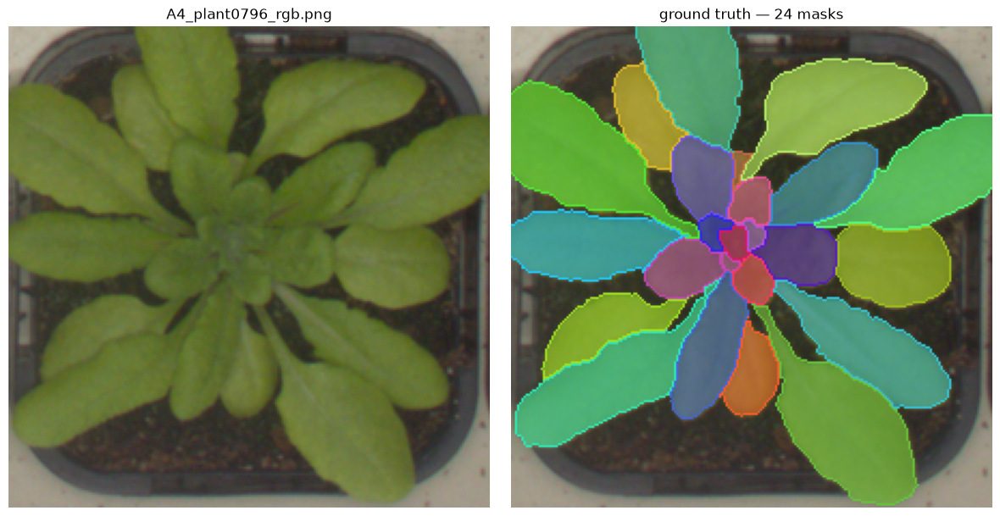

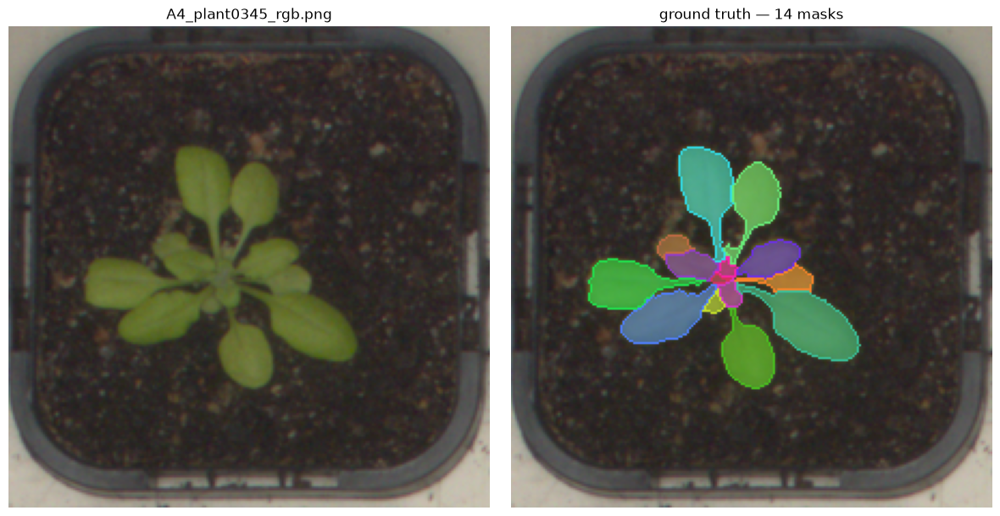

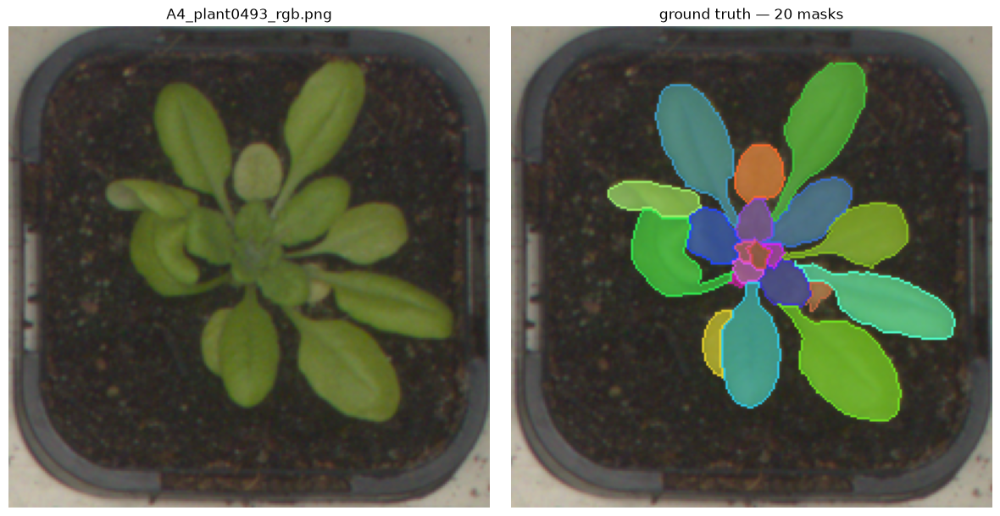

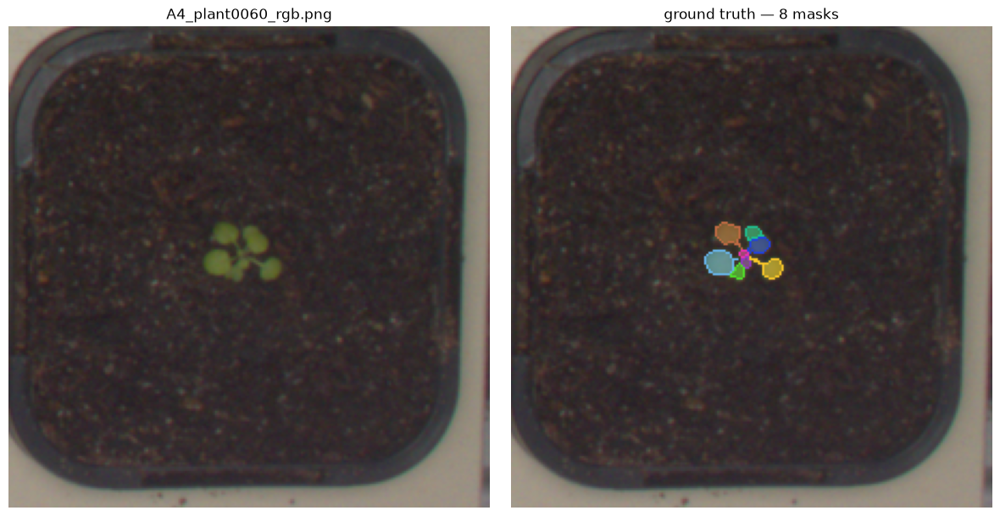

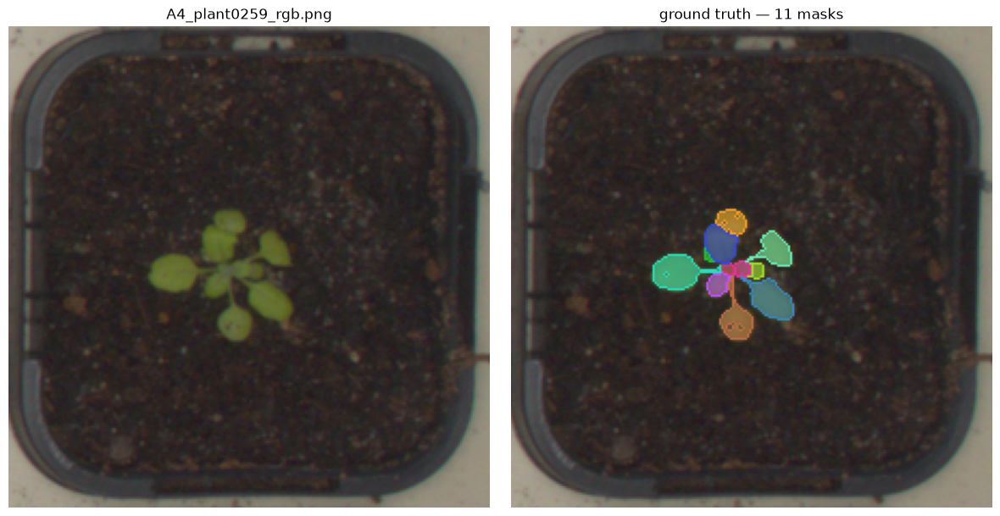

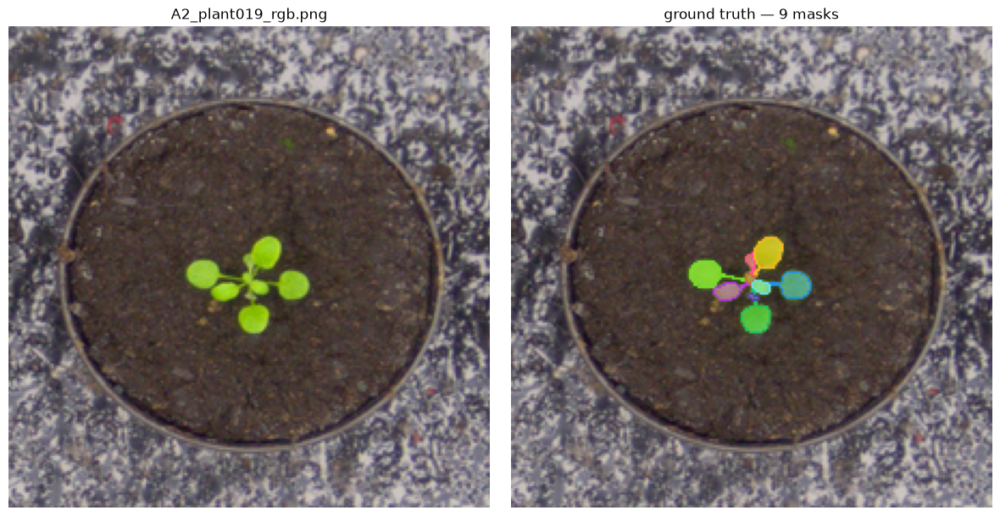

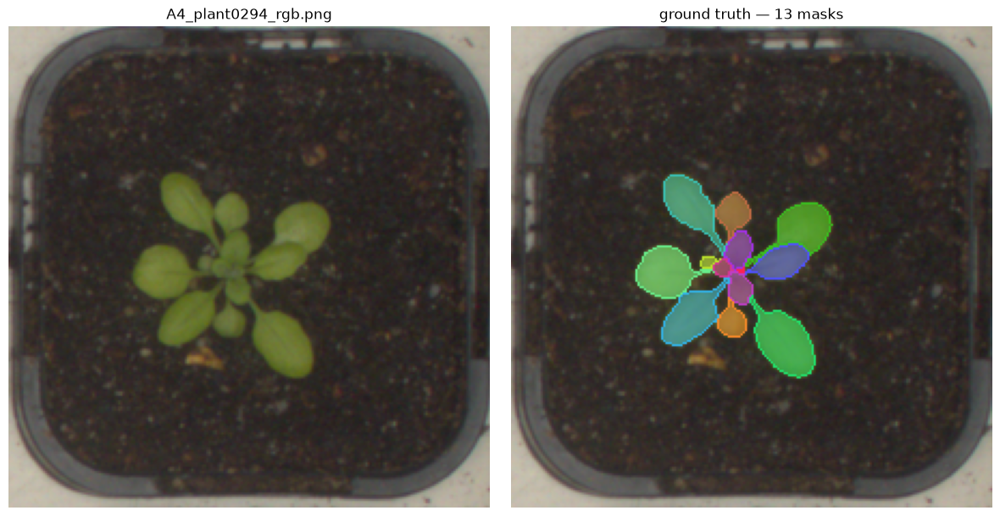

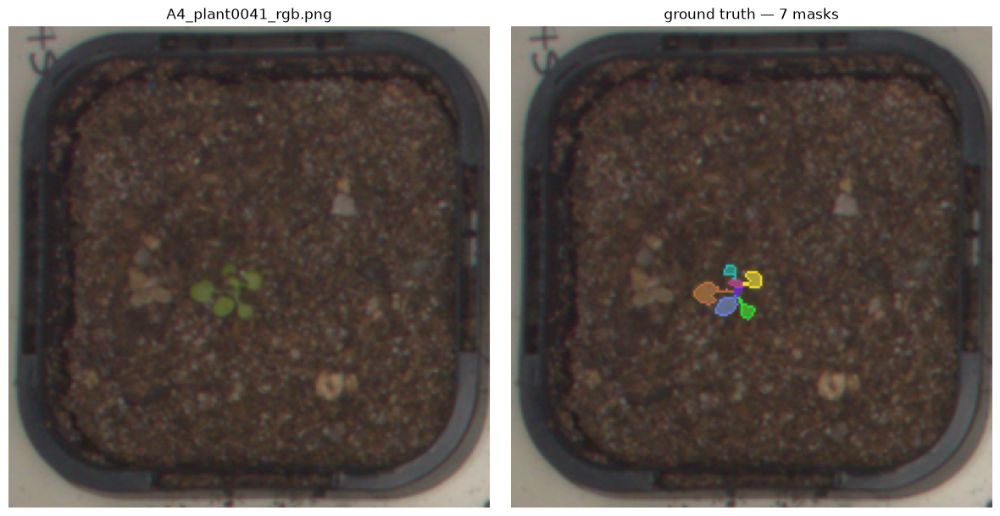

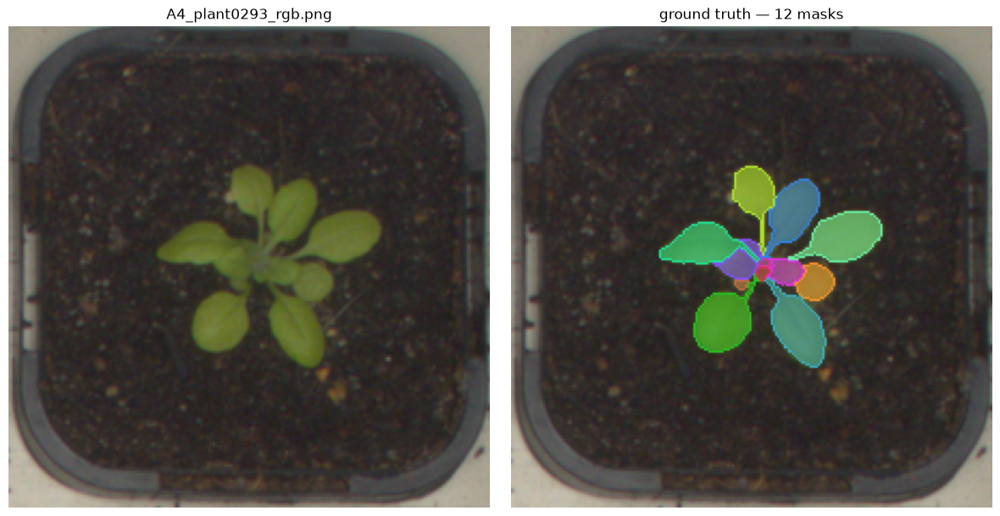

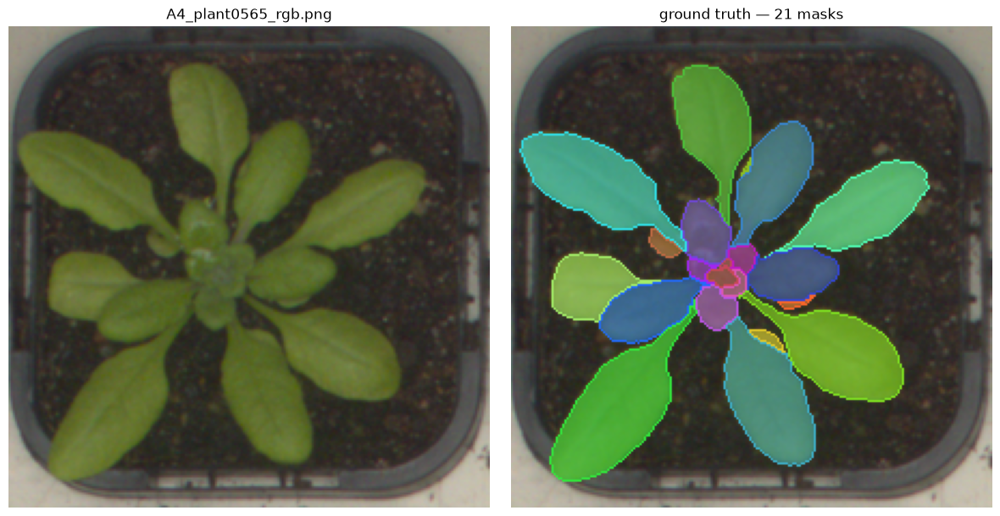

In [7]:
SAMPLE_N = 10
SEED = 42

for row in TEST_DATA.sample(SAMPLE_N, random_state=SEED).itertuples(index=False):
    image = load_image(row.image_path)
    gt_masks = get_masks_from_label_image(load_label_image(row.label_path))

    show_masks({"image_name": row.image, "image": image, "masks": gt_masks},
               "ground truth")

In [8]:
# Set the output directory of whatever results produced by the models
OUTPUT_ROOT = os.path.join(REPO_ROOT, "output_notebook")

def output_dir(model_name):
    """Per-model output folder for the current subset, e.g. output_notebook/01_sam2/A1."""
    return os.path.join(OUTPUT_ROOT, model_name, 'output')

# 4. Model experiment

## 4.1 SAM 2

Meta's foundation segmenter, run in **automatic mask** mode: it segments
*everything* (leaves, pot, soil, background) with no training, and we keep the
**green, mid-sized** masks as candidate leaves. Weights auto-download from
Hugging Face on first run.

In [12]:
import torch

# ---------------------------------------------------------------------------
# How SAM works (Segment Anything Model, here SAM 2.1)
#
# SAM is a *promptable* segmenter. It splits the work in two:
#   1. a heavy image encoder (SAM 2 uses a Hiera vision transformer) runs ONCE
#      per image and turns it into an embedding;
#   2. a tiny mask decoder turns a *prompt* — a click, a box, a rough mask —
#      into a segmentation mask in milliseconds, reusing that embedding.
# So prompting the same image 1000 times is cheap: only step 2 repeats.
#
# Crucially SAM is CLASS-AGNOSTIC. It was trained on ~1B masks to answer "what
# object is here?", never "what kind of object is this?". It has no notion of a
# leaf, and returns masks with no labels — only geometry plus a quality score.
#
# "Automatic mask generation" is SAM run with no human prompts: it lays a
# regular POINTS_PER_SIDE x POINTS_PER_SIDE grid of foreground points over the
# image and prompts itself with each one. For every point the decoder proposes
# three nested candidates (subpart / part / whole — e.g. leaf tip, leaf, whole
# plant) to resolve the ambiguity of what a single click means. Candidates are
# then pruned by predicted IoU (the model's own confidence), by a stability
# score (does the mask survive nudging the binarisation threshold?), and by NMS
# to drop near-duplicates from neighbouring grid points.
#
# What comes back is therefore "segment everything": dozens of overlapping,
# nested, unlabelled masks covering leaves, soil, pot, ruler and background
# alike. Picking the leaves out of that pile is our job, not SAM's — that is
# what MIN_GREEN / MIN_AREA / MAX_AREA do in filter_leaf_masks() below.
#
# SAM 2 extends SAM 1 with a memory bank for tracking objects across video
# frames; on single stills that memory stays empty, so it acts as a faster,
# stronger SAM 1.
# ---------------------------------------------------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Grid of self-prompts: 32 x 32 = 1024 points per image. Denser grids find more
# small leaves but cost proportionally more decoder passes (they run in batches,
# so time grows faster than VRAM). Drop to 16 (256 points) if you hit OOM.
POINTS_PER_SIDE = 32   # standard number of points to cover per image

# The three "is this a leaf?" heuristics SAM cannot supply itself, since it
# returns unlabelled masks of everything it can see:
MIN_GREEN = 0.5        # min fraction of green pixels for a mask to count as a leaf
MIN_AREA = 0.0005      # drop masks smaller than this fraction of the image
MAX_AREA = 0.25        # drop masks larger than this fraction (usually background)

MODEL_IDS = {
    "tiny": "facebook/sam2.1-hiera-tiny",
    "small": "facebook/sam2.1-hiera-small",
    "base-plus": "facebook/sam2.1-hiera-base-plus",
    "large": "facebook/sam2.1-hiera-large",
}
MODEL_SIZE = "tiny"   # tiny / small; large may cause OOM


In [13]:
def build_mask_generator(model_id):
    """Load pretrained SAM 2 weights and wrap them in an automatic mask generator."""
    from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

    # Newer sam2 exposes .from_pretrained on the generator; fall back to build_sam2_hf.
    try:
        return SAM2AutomaticMaskGenerator.from_pretrained(
            model_id, device=DEVICE, points_per_side=POINTS_PER_SIDE
        )
    except (AttributeError, TypeError):
        from sam2.build_sam import build_sam2_hf

        model = build_sam2_hf(model_id, device=DEVICE)
        return SAM2AutomaticMaskGenerator(model, points_per_side=POINTS_PER_SIDE)


def filter_leaf_masks(image, anns):
    """Keep only mid-sized, mostly-green masks -- SAM 2 is class-agnostic, so this
    is how we pick the leaves out of its "segment everything" output."""
    total = image.shape[0] * image.shape[1]
    kept = []
    for a in anns:
        seg = a["segmentation"].astype(bool)
        area = seg.sum()
        if area < MIN_AREA * total or area > MAX_AREA * total:
            continue
        if MIN_GREEN > 0 and green_fraction(image, seg) < MIN_GREEN:
            continue
        kept.append(seg)
    return kept

### Run it on the test split

In [14]:
print(f"Loading SAM 2 ({MODEL_IDS[MODEL_SIZE]}) on {DEVICE} ...")
gen = build_mask_generator(MODEL_IDS[MODEL_SIZE])

all_masks, timings = [], [], []
for row in TEST_DATA.itertuples(index=False):
    image = load_image(row.image_path)

    # inference
    t0 = time.perf_counter()
    with torch.inference_mode():
        anns = gen.generate(image)
    t1 = time.perf_counter()

    # post processing
    masks = filter_leaf_masks(image, anns)
    t2 = time.perf_counter()

    # saving of data
    timings.append((row.image, t1 - t0, t2 - t1))
    all_masks.append({"image_name": row.image, "image": image, "masks": masks})
    print(f"{row.image}: {len(anns)} raw masks -> {len(masks)} kept")

out = output_dir("01_sam2")
save_outputs(out, all_masks, "sam2")
save_timings_csv(os.path.join(out, "timings.csv"), timings)
print("wrote ->", out)

Loading SAM 2 (facebook/sam2.1-hiera-tiny) on cuda ...


/home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A1_plant008_rgb.png: 9 raw masks -> 8 kept
A1_plant017_rgb.png: 10 raw masks -> 6 kept
A1_plant024_rgb.png: 13 raw masks -> 9 kept
A1_plant037_rgb.png: 19 raw masks -> 13 kept
A1_plant043_rgb.png: 14 raw masks -> 11 kept
A1_plant044_rgb.png: 12 raw masks -> 9 kept
A1_plant047_rgb.png: 19 raw masks -> 13 kept
A1_plant049_rgb.png: 10 raw masks -> 6 kept
A1_plant057_rgb.png: 16 raw masks -> 10 kept
A1_plant063_rgb.png: 10 raw masks -> 7 kept
A1_plant065_rgb.png: 13 raw masks -> 9 kept
A1_plant076_rgb.png: 12 raw masks -> 8 kept
A1_plant077_rgb.png: 14 raw masks -> 11 kept
A1_plant079_rgb.png: 16 raw masks -> 12 kept
A1_plant080_rgb.png: 16 raw masks -> 12 kept
A1_plant091_rgb.png: 14 raw masks -> 11 kept
A1_plant099_rgb.png: 14 raw masks -> 11 kept
A1_plant120_rgb.png: 18 raw masks -> 9 kept
A1_plant121_rgb.png: 15 raw masks -> 9 kept
A1_plant123_rgb.png: 9 raw masks -> 6 kept
A1_plant126_rgb.png: 17 raw masks -> 10 kept
A1_plant128_rgb.png: 8 raw masks -> 7 kept
A1_plant133_rgb.png: 11 r

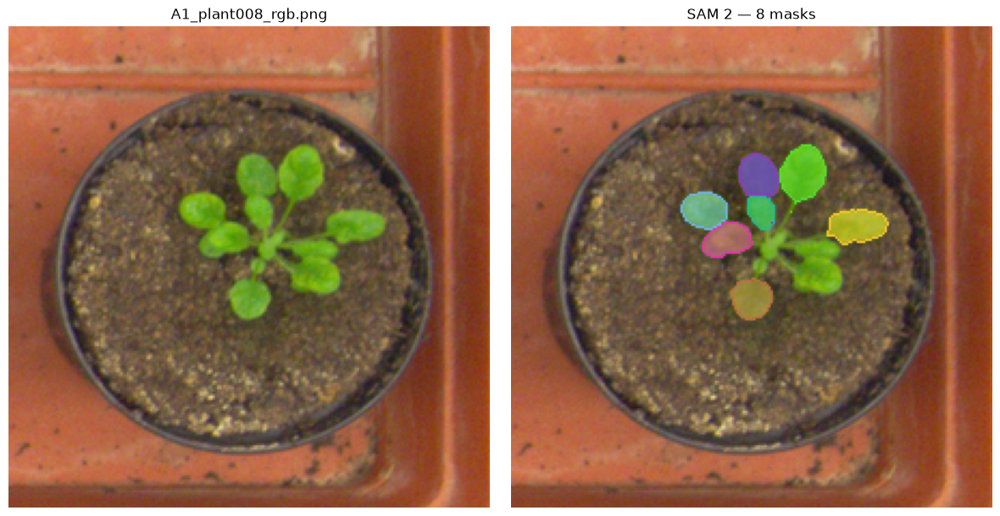

In [15]:
show_masks(all_masks[0], "SAM 2")

## 4.2 Leaf Only SAM

The original **SAM v1** automatic mask generator with the paper's settings
(Williams et al., 2023), followed by the paper's four filters: green colour →
whole-plant removal → leaf shape → composite removal.

In [16]:
import cv2
import numpy as np
import torch

CKPT_DIR = os.path.join(REPO_ROOT, "checkpoints")
POINTS_PER_SIDE = 32
MIN_SHAPE = 0.1        # checkshape: min contour-area / enclosing-circle area
SUBSET_THRESH = 0.9    # remove_toobig: overlap fraction to count as contained
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CKPTS = {
    "vit_b": ("sam_vit_b_01ec64.pth",
              "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"),
    "vit_l": ("sam_vit_l_0b3195.pth",
              "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth"),
    "vit_h": ("sam_vit_h_4b8939.pth",
              "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"),
}
MODEL_TYPE = "vit_b"   # chose the smallest size to avoid OOM errors

In [17]:
import urllib.request

def ensure_checkpoint(model_type):
    fname, url = CKPTS[model_type]
    os.makedirs(CKPT_DIR, exist_ok=True)
    path = os.path.join(CKPT_DIR, fname)
    if not os.path.exists(path):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, path)
    return path


def build_generator(model_type, ckpt):
    from segment_anything import SamAutomaticMaskGenerator, sam_model_registry

    sam = sam_model_registry[model_type](checkpoint=ckpt).to(DEVICE)
    return SamAutomaticMaskGenerator(
        sam,
        points_per_side=POINTS_PER_SIDE,
        pred_iou_thresh=0.88,
        stability_score_thresh=0.95,
        crop_n_layers=1,
        crop_n_points_downscale_factor=2,
        min_mask_region_area=200,
    )

### The paper's four leaf filters

Code is taken from github: https://github.com/Dom3442/leafonlysam/blob/main/Leaf%20Only%20SAM.ipynb

In [18]:
def _select(masks, keep):
    return [m for m, k in zip(masks, keep) if k]


def iou(a, b):
    union = np.logical_or(a, b).sum()
    return np.logical_and(a, b).sum() / union if union else 0.0


def checkcolour(hsv, masks):
    """Keep masks whose mean HSV colour is green (grow-light fallback widens hue)."""
    means = np.zeros((len(masks), 3))
    for i, m in enumerate(masks):
        if m.any():
            means[i] = hsv[m].mean(axis=0)
    h, s = means[:, 0], means[:, 1]
    idx = (h < 75) & (h > 35) & (s > 35)
    if idx.sum() == 0:                       # grow-light fallback: widen hue band
        idx = (h < 100) & (h > 35) & (s > 35)
    return idx


def checkfullplant(masks):
    """Drop any mask that is ~the union of all masks (the whole-plant blob)."""
    union = np.zeros_like(masks[0], dtype=bool)
    for m in masks:
        union |= m
    return np.array([iou(m, union) < 0.9 for m in masks])


def shape_ratio(mask):
    """Compactness: largest-contour area / its min-enclosing-circle area."""
    cnts, _ = cv2.findContours(mask.astype(np.uint8) * 255,
                               cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return 0.0
    cnt = max(cnts, key=len)
    (_, _), radius = cv2.minEnclosingCircle(cnt)
    carea = np.pi * radius ** 2
    return cv2.contourArea(cnt) / carea if carea > 0 else 0.0


def remove_toobig(masks):
    """Drop composite masks that are just their own smaller sub-masks stacked."""
    keep = [True] * len(masks)
    for i, big in enumerate(masks):
        big_area = int(big.sum())
        if big_area == 0:
            keep[i] = False
            continue
        covered = np.zeros_like(big)
        found = False
        for j, other in enumerate(masks):
            if i == j or not keep[j]:
                continue
            oa = int(other.sum())
            if oa and np.logical_and(other, big).sum() / oa > SUBSET_THRESH:
                covered |= other
                found = True
        if found and np.logical_and(big, covered).sum() / big_area > 0.9:
            keep[i] = False
    return _select(masks, keep)


def leaf_only_filter(image, anns):
    masks = [a["segmentation"].astype(bool) for a in anns]
    if not masks:
        return []
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)   # paper feeds RGB through BGR->HSV
    masks = _select(masks, checkcolour(hsv, masks))          # 1. green colour
    if len(masks) > 2:                                       # 2. drop whole-plant mask
        masks = _select(masks, checkfullplant(masks))
    masks = [m for m in masks if shape_ratio(m) > MIN_SHAPE]  # 3. leaf shape
    return remove_toobig(masks)                              # 4. drop composites

### Run it on the test split

In [19]:
gen = build_generator(MODEL_TYPE, ensure_checkpoint(MODEL_TYPE))
print(f"Loaded SAM ({MODEL_TYPE}) on {DEVICE}")

all_masks, timings = [], [], []
for row in TEST_DATA.itertuples(index=False):
    image = load_image(row.image_path)

    # inference
    t0 = time.perf_counter()
    with torch.inference_mode():
        anns = gen.generate(image)
    t1 = time.perf_counter()

    # post processing
    masks = leaf_only_filter(image, anns)
    t2 = time.perf_counter()

    # saving of data
    timings.append((row.image, t1 - t0, t2 - t1))
    all_masks.append({"image_name": row.image, "image": image, "masks": masks})
    print(f"{row.image}: {len(anns)} raw -> {len(masks)} leaves")

out = output_dir("02_leaf_only_sam")
save_outputs(out, all_masks, "leafonlysam")
save_timings_csv(os.path.join(out, "timings.csv"), timings)
print("wrote ->", out)

Loaded SAM (vit_b) on cuda


[W805 14:15:03.590495580 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 805306368 bytes (free: 737148928, total: 6071123968).


A1_plant008_rgb.png: 26 raw -> 12 leaves
A1_plant017_rgb.png: 25 raw -> 13 leaves
A1_plant024_rgb.png: 31 raw -> 9 leaves
A1_plant037_rgb.png: 41 raw -> 21 leaves
A1_plant043_rgb.png: 28 raw -> 2 leaves
A1_plant044_rgb.png: 23 raw -> 6 leaves
A1_plant047_rgb.png: 43 raw -> 5 leaves
A1_plant049_rgb.png: 31 raw -> 17 leaves
A1_plant057_rgb.png: 23 raw -> 2 leaves
A1_plant063_rgb.png: 23 raw -> 1 leaves
A1_plant065_rgb.png: 40 raw -> 19 leaves
A1_plant076_rgb.png: 28 raw -> 15 leaves
A1_plant077_rgb.png: 29 raw -> 21 leaves
A1_plant079_rgb.png: 29 raw -> 3 leaves
A1_plant080_rgb.png: 29 raw -> 2 leaves
A1_plant091_rgb.png: 20 raw -> 1 leaves
A1_plant099_rgb.png: 29 raw -> 3 leaves
A1_plant120_rgb.png: 49 raw -> 7 leaves
A1_plant121_rgb.png: 35 raw -> 9 leaves
A1_plant123_rgb.png: 27 raw -> 1 leaves
A1_plant126_rgb.png: 40 raw -> 13 leaves
A1_plant128_rgb.png: 24 raw -> 8 leaves
A1_plant133_rgb.png: 26 raw -> 5 leaves
A1_plant137_rgb.png: 34 raw -> 4 leaves
A1_plant142_rgb.png: 29 raw -> 1

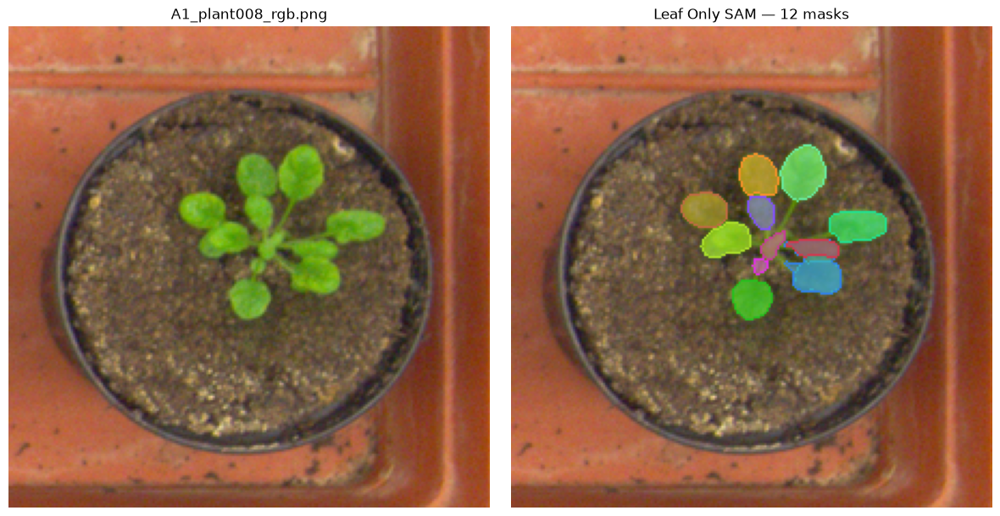

In [20]:
show_masks(all_masks[0], "Leaf Only SAM")

## 4.3 HQ-SAM — zero-shot

SAM with a high-quality mask decoder — sharper boundaries on thin, serrated leaf
edges. Same automatic-mask + green-filter recipe as § 2, different decoder.
`vit_tiny` is "Light HQ-SAM".

In [12]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
POINTS_PER_SIDE = 32
MIN_GREEN = 0.5        # min fraction of green pixels for a mask to count as a leaf
MIN_AREA = 0.0005      # drop masks smaller than this fraction of the image
MAX_AREA = 0.25        # drop masks larger than this fraction (usually background)

HF_REPO = "lkeab/hq-sam"
CKPT_FILES = {
    "vit_tiny": "sam_hq_vit_tiny.pth",  # Light HQ-SAM
    "vit_b": "sam_hq_vit_b.pth",
    "vit_l": "sam_hq_vit_l.pth",
    "vit_h": "sam_hq_vit_h.pth",
}
MODEL_TYPE = "vit_tiny"   # best fit for 6 GB VRAM

In [13]:
def ensure_checkpoint(model_type):
    from huggingface_hub import hf_hub_download

    try:
        return hf_hub_download(HF_REPO, CKPT_FILES[model_type])
    except Exception as e:  # noqa: BLE001
        sys.exit(
            f"Could not auto-download {CKPT_FILES[model_type]} from {HF_REPO} ({e}).\n"
            "Download it manually (see README) and place it in the HF cache."
        )


def build_generator(model_type, ckpt):
    from segment_anything_hq import SamAutomaticMaskGenerator, sam_model_registry

    sam = sam_model_registry[model_type](checkpoint=ckpt).to(DEVICE)
    return SamAutomaticMaskGenerator(sam, points_per_side=POINTS_PER_SIDE)


def filter_leaf_masks(image, anns):
    total = image.shape[0] * image.shape[1]
    kept = []
    for a in anns:
        seg = a["segmentation"].astype(bool)
        area = seg.sum()
        if area < MIN_AREA * total or area > MAX_AREA * total:
            continue
        if MIN_GREEN > 0 and green_fraction(image, seg) < MIN_GREEN:
            continue
        kept.append(seg)
    return kept

### Run it on the test split

In [14]:
print(f"Loading HQ-SAM ({MODEL_TYPE}) on {DEVICE} ...")
gen = build_generator(MODEL_TYPE, ensure_checkpoint(MODEL_TYPE))

all_masks, timings = [], [], []
for row in TEST_DATA.itertuples(index=False):
    image = load_image(row.image_path)

    # inference
    t0 = time.perf_counter()
    with torch.inference_mode():
        anns = gen.generate(image)
    t1 = time.perf_counter()

    # post processing
    masks = filter_leaf_masks(image, anns)
    t2 = time.perf_counter()

    # saving of data
    timings.append((row.image, t1 - t0, t2 - t1))
    all_masks.append({"image_name": row.image, "image": image, "masks": masks})
    print(f"{row.image}: {len(anns)} raw -> {len(masks)} kept")

out = output_dir("03_hq_sam")
save_outputs(out, all_masks, "hqsam")
save_timings_csv(os.path.join(out, "timings.csv"), timings)
print("wrote ->", out)

Loading HQ-SAM (vit_tiny) on cuda ...


/home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/.venv/lib/python3.14/site-packages/segment_anything_hq/modeling/tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_5m_224 in registry with segment_anything_hq.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/.venv/lib/python3.14/site-packages/segment_anything_hq/modeling/tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_11m_224 in registry with segment_anything_hq.modeling.tiny_vit_sam.tiny_vit_11m_224. This is

<All keys matched successfully>


[W805 14:44:18.789919943 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 1073741824 bytes (free: 927137792, total: 6071123968).
[W805 14:44:19.903699535 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 1073741824 bytes (free: 1031995392, total: 6071123968).
[W805 14:44:19.970018651 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 1073741824 bytes (free: 497221632, total: 6071123968).
[W805 14:44:19.970104956 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 1073741824 bytes (free: 497221632, total: 6071123968).


OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 0 has a total capacity of 5.65 GiB of which 474.19 MiB is free. Process 1135 has 28.16 MiB memory in use. Process 1804 has 194.53 MiB memory in use. Process 2767 has 95.03 MiB memory in use. Process 12181 has 70.09 MiB memory in use. Including non-PyTorch memory, this process has 4.47 GiB memory in use. Of the allocated memory 4.10 GiB is allocated by PyTorch, and 265.29 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
show_masks(all_masks[0], "HQ-SAM")

## 4.4 Mask R-CNN — fine-tune

The torchvision Mask R-CNN. COCO has no "leaf" class, so the COCO weights are
only a baseline — the accuracy comes from **fine-tuning on the `fine_tuning/`
split**: every leaf is one foreground class, so `num_classes = 2`
(background + leaf). Training reads each `images/A?/plantNNN_rgb.png` paired with
its label map `per_leaf_mask/A?/plantNNN_label.png`.

### 4a. Fine-tune on the training split

In [12]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 2        # background + leaf
EPOCHS = 10
BATCH_SIZE = 2         # keep small on a 6 GB GPU; drop to 1 if you hit OOM
MASKRCNN_DIR = output_dir("04_mask_rcnn")   # output_notebook/04_mask_rcnn/all
MASKRCNN_WEIGHTS = os.path.join(MASKRCNN_DIR, "finetuned_maskrcnn.pth")

In [13]:
class LeafDataset(torch.utils.data.Dataset):
    """Turns each (image, label map) row into the (image, target) Mask R-CNN wants."""

    def __init__(self, data):
        self.images = data["image_path"].tolist()
        self.labels = data["label_path"].tolist()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        image = load_image(self.images[i])
        label_map = load_label_image(self.labels[i])

        # one boolean mask + box per leaf; empty and 1-pixel-thin leaves are skipped
        # because a zero-area box makes the loss NaN
        boxes, masks = [], []
        for m in get_masks_from_label_image(label_map):
            ys, xs = np.where(m)
            if xs.size and xs.min() < xs.max() and ys.min() < ys.max():
                boxes.append([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1])
                masks.append(m)

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.ones(len(masks), dtype=torch.int64),   # every leaf = class 1
            "masks": torch.as_tensor(np.array(masks), dtype=torch.uint8),
        }
        image = torch.from_numpy(image).permute(2, 0, 1).float().div(255)
        return image, target


def build_model():
    """COCO-pretrained Mask R-CNN with its two heads swapped for NUM_CLASSES outputs."""
    import torchvision
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)
    in_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, NUM_CLASSES)
    return model.to(DEVICE)

In [14]:
print(f"Training on {len(TRAIN_DATA)} images, {EPOCHS} epochs, on {DEVICE}")

# images have different sizes, so batches stay as lists (collate = zip)
loader = torch.utils.data.DataLoader(
    LeafDataset(TRAIN_DATA), batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=lambda batch: tuple(zip(*batch)))

model = build_model()
model.train()
optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad],
                            lr=0.005, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS):
    running = 0.0
    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss = sum(model(images, targets).values())   # train mode returns a loss dict

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()

    print(f"epoch {epoch + 1}/{EPOCHS}  mean loss {running / len(loader):.4f}")

Training on 648 images, 10 epochs, on cuda
epoch 1/10  mean loss 0.9854
epoch 2/10  mean loss 0.7464
epoch 3/10  mean loss 0.6723
epoch 4/10  mean loss 0.6183
epoch 5/10  mean loss 0.5749
epoch 6/10  mean loss 0.5386
epoch 7/10  mean loss 0.5044
epoch 8/10  mean loss 0.4784
epoch 9/10  mean loss 0.4563
epoch 10/10  mean loss 0.4332


In [15]:
torch.save(model.state_dict(), MASKRCNN_WEIGHTS)   # plain state_dict, as run_* loads
print(f"Saved fine-tuned weights -> {MASKRCNN_WEIGHTS}")

Saved fine-tuned weights -> /home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/output_notebook/04_mask_rcnn/output/finetuned_maskrcnn.pth


### 4b. Run on testing split

`build_model` below is `run_mask_rcnn.py`'s version — it rebuilds the 2-class
heads and loads the fine-tuned `state_dict` (or falls back to the COCO baseline
if you skipped training). Re-run the cell in 5a to get the trainer's builder back.

In [19]:
SCORE_THRESH = 0.5     # min detection confidence to keep an instance
MASK_THRESH = 0.5      # threshold on the soft mask to binarise it


def build_model(weights_path):
    import torchvision
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

    if weights_path:
        # your fine-tuned model: build with matching #classes, then load state dict
        model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)
        in_feat = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)
        in_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
        model.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, NUM_CLASSES)
        model.load_state_dict(torch.load(weights_path, map_location="cpu"))
    else:
        weights = torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
        model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=weights)
    return model.eval().to(DEVICE)

In [20]:
weights = MASKRCNN_WEIGHTS if os.path.exists(MASKRCNN_WEIGHTS) else None  # None = COCO

print(f"Loading Mask R-CNN on {DEVICE} "
      f"({'fine-tuned ' + weights if weights else 'COCO-pretrained'}) ...")
model = build_model(weights)

all_masks, timings = [], [], []
for path in TEST_IMAGES:
    image = load_image(path)

    # inference
    t0 = time.perf_counter()
    tensor = torch.from_numpy(image).permute(2, 0, 1).float().div(255).to(DEVICE)
    with torch.inference_mode():
        pred = model([tensor])[0]
    t1 = time.perf_counter()

    # post processing
    keep = pred["scores"].cpu().numpy() >= SCORE_THRESH
    masks = list(pred["masks"].cpu().numpy()[keep, 0] > MASK_THRESH)  # (N, H, W) bool
    t2 = time.perf_counter()

    # saving of data
    image_name = os.path.basename(path)
    timings.append((image_name, t1 - t0, t2 - t1))
    all_masks.append({"image_name": image_name, "image": image, "masks": masks})
    print(f"{image_name}: {len(masks)} instances (score>={SCORE_THRESH})")

out = output_dir("04_mask_rcnn")
save_outputs(out, all_masks, "maskrcnn")
save_timings_csv(os.path.join(out, "timings.csv"), timings)
print("wrote ->", out)

Loading Mask R-CNN on cuda (fine-tuned /home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/output_notebook/04_mask_rcnn/output/finetuned_maskrcnn.pth) ...
A1_plant008_rgb.png: 13 instances (score>=0.5)
A1_plant017_rgb.png: 11 instances (score>=0.5)
A1_plant024_rgb.png: 17 instances (score>=0.5)
A1_plant037_rgb.png: 20 instances (score>=0.5)
A1_plant043_rgb.png: 19 instances (score>=0.5)
A1_plant044_rgb.png: 16 instances (score>=0.5)
A1_plant047_rgb.png: 20 instances (score>=0.5)
A1_plant049_rgb.png: 14 instances (score>=0.5)
A1_plant057_rgb.png: 15 instances (score>=0.5)
A1_plant063_rgb.png: 18 instances (score>=0.5)
A1_plant065_rgb.png: 17 instances (score>=0.5)
A1_plant076_rgb.png: 15 instances (score>=0.5)
A1_plant077_rgb.png: 18 instances (score>=0.5)
A1_plant079_rgb.png: 19 instances (score>=0.5)
A1_plant080_rgb.png: 19 instances (score>=0.5)
A1_plant091_rgb.png: 18 instances (score>=0.5)
A1_plant099_rgb.png: 20 instances (score>=0.5)
A1_plant120_rgb.png: 15 instance

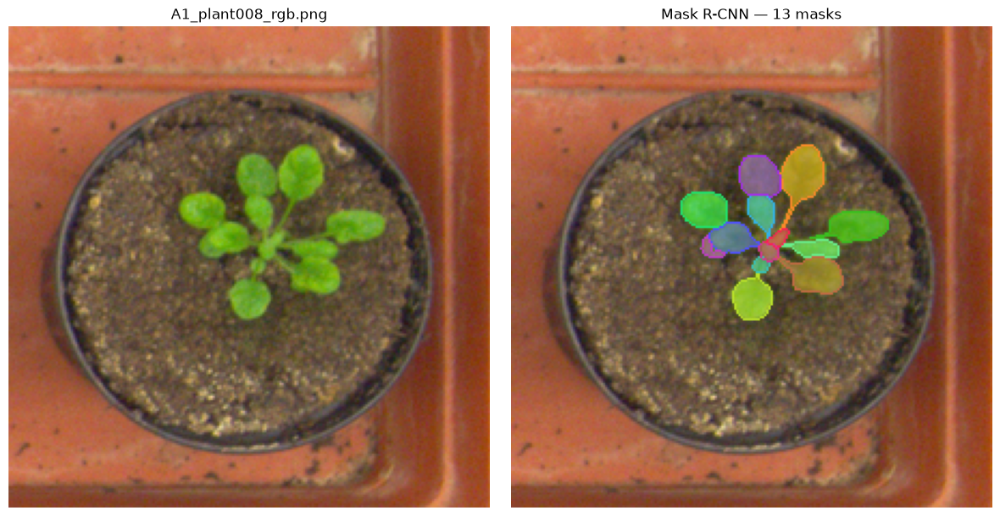

In [21]:
show_masks(all_masks[0], "Mask R-CNN")

## 4.5 YOLO11-seg — convert labels, fine-tune, then run

Three steps, because Ultralytics can't read the CVPPP label-map PNGs:

1. **Convert** each leaf in `per_leaf_mask/` into a normalized polygon
   (`0 x1 y1 x2 y2 …`) and lay the files out as `images/{train,val}` +
   `labels/{train,val}` — `fine_tuning/` becomes `train`, `testing/` becomes
   `val`. Filenames get an `A1_`/`A2_` prefix because the subsets reuse
   `plantNNN` names.
2. **Train** from the COCO-pretrained `yolo11n-seg.pt`.
3. **Run** the fine-tuned `best.pt` over the test images.

### 5a. Preprocessing: CVPPP label maps → YOLO-seg polygons

In [12]:
SPLITS = {"fine_tuning": "train", "testing": "val"}   # source split -> YOLO split
EPSILON = 1.0          # polygon simplification in pixels (0 = keep every point)
YOLO_DIR = output_dir("05_yolo_seg")   # output_notebook/04_mask_rcnn/all
YOLO_DATASET = os.path.join(YOLO_DIR, "yolo_dataset")
YOLO_YAML = os.path.join(YOLO_DIR, "leaf.yaml")

In [13]:
def mask_to_polygon(mask, w, h, epsilon):
    """Trace one leaf's boolean mask into a normalized polygon string, or None."""
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)          # biggest blob if the leaf fragmented
    if epsilon > 0:
        c = cv2.approxPolyDP(c, epsilon, True)  # fewer points, same shape
    c = c.reshape(-1, 2)
    if len(c) < 3:
        return None                             # need >= 3 points for a polygon
    return "0 " + " ".join(f"{x / w:.6f} {y / h:.6f}" for x, y in c)


def label_map_to_lines(label_path, epsilon):
    """All leaf polygons in one label map, as a list of YOLO-seg text lines."""
    label_map = np.array(Image.open(label_path))
    h, w = label_map.shape
    lines = []
    for leaf_id in np.unique(label_map):
        if leaf_id == 0:                        # 0 = background
            continue
        mask = (label_map == leaf_id).astype(np.uint8)
        line = mask_to_polygon(mask, w, h, epsilon)
        if line:
            lines.append(line)
    return lines


def convert_split(data_root, src, dst, out, epsilon):
    """Convert one source split (e.g. fine_tuning -> train). Returns #images written."""
    label_paths = sorted(glob.glob(
        os.path.join(data_root, src, "per_leaf_mask", "*", "*_label.png")))
    if not label_paths:
        print(f"  no label maps under {data_root}/{src} -- skipped")
        return 0

    img_out = os.path.join(out, "images", dst)
    lbl_out = os.path.join(out, "labels", dst)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    count = 0
    for label_path in label_paths:
        subset = os.path.basename(os.path.dirname(label_path))       # A1, A2, ...
        stem = os.path.basename(label_path).replace("_label.png", "_rgb")
        image_path = os.path.join(data_root, src, "images", subset, stem + ".png")
        if not os.path.exists(image_path):
            continue

        lines = label_map_to_lines(label_path, epsilon)
        name = f"{subset}_{stem}"                                    # A1_plant006_rgb
        with open(os.path.join(lbl_out, name + ".txt"), "w") as f:
            f.write("\n".join(lines))
        shutil.copy(image_path, os.path.join(img_out, name + ".png"))
        count += 1

    print(f"  {src} -> {dst}: {count} images")
    return count


def write_yaml(yaml_path, out):
    """Write the Ultralytics dataset yaml pointing at the converted data."""
    with open(yaml_path, "w") as f:
        f.write(f"path: {os.path.abspath(out)}\n")
        f.write("train: images/train\n")
        f.write("val: images/val\n")
        f.write("names:\n  0: leaf\n")
    print(f"Wrote {yaml_path} (path -> {os.path.abspath(out)})")

In [14]:
total = 0
for src, dst in SPLITS.items():
    total += convert_split(DATA_ROOT, src, dst, YOLO_DATASET, EPSILON)
if total == 0:
    raise SystemExit(f"No images converted -- check DATA_ROOT ({DATA_ROOT}).")

write_yaml(YOLO_YAML, YOLO_DATASET)
print(f"Done: {total} images.")

  fine_tuning -> train: 648 images
  testing -> val: 162 images
Wrote /home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/output_notebook/05_yolo_seg/output/leaf.yaml (path -> /home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/output_notebook/05_yolo_seg/output/yolo_dataset)
Done: 810 images.


### 5b. Fine-tune YOLO11-seg

Weights land in `runs/segment/train/weights/best.pt`. Keep `BATCH` small to avoid OOM errors.

In [15]:
BASE_MODEL = "yolo11n-seg.pt"   # COCO weights auto-download; n/s train fine on 6 GB
EPOCHS = 32
IMGSZ = 640
BATCH = 4
DEVICE = 0 if torch.cuda.is_available() else "cpu"   # 0 = first GPU

model = YOLO(BASE_MODEL)
model.train(data=YOLO_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, device=DEVICE)
# weights land in runs/segment/train*/weights/best.pt
metrics = model.val()
print("Validation:", metrics.results_dict if hasattr(metrics, "results_dict") else metrics)

YOLO_WEIGHTS = model.trainer.best
print("best weights ->", YOLO_WEIGHTS)

Ultralytics 8.4.115 🚀 Python-3.14.6 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5790MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/output_notebook/05_yolo_seg/output/leaf.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tr

### 6c. Run it on the test split

In [16]:
import numpy as np
import torch

DEVICE = 0 if torch.cuda.is_available() else "cpu"   # 0 = first GPU
CONF = 0.25            # min detection confidence
IMGSZ = 640            # inference image size

if "YOLO_WEIGHTS" not in globals():                  # skipped 6b?
    YOLO_WEIGHTS = "yolo11n-seg.pt"                  # COCO baseline, or your own best.pt


def extract_masks(res, image):
    """Return a YOLO result's instance masks at the original image resolution."""
    if res.masks is None:
        return []
    h, w = image.shape[:2]
    masks = []
    for m in res.masks.data.cpu().numpy():   # (N, h', w') float
        if m.shape != (h, w):
            from PIL import Image
            m = np.asarray(Image.fromarray((m * 255).astype(np.uint8)).resize((w, h))) > 127
        else:
            m = m > 0.5
        masks.append(m)
    return masks

In [17]:
from ultralytics import YOLO

print(f"Loading YOLO-seg ({YOLO_WEIGHTS}) on device {DEVICE} ...")
model = YOLO(YOLO_WEIGHTS)

all_masks, timings = [], [], []
for path in TEST_IMAGES:
    image = load_image(path)

    # inference
    t0 = time.perf_counter()
    # PIL input keeps the RGB order (a raw numpy array is read as BGR)
    res = model.predict(Image.fromarray(image), conf=CONF, imgsz=IMGSZ,
                        device=DEVICE, verbose=False)[0]
    t1 = time.perf_counter()

    # post processing
    masks = extract_masks(res, image)
    t2 = time.perf_counter()

    # saving of data
    image_name = os.path.basename(path)
    timings.append((image_name, t1 - t0, t2 - t1))
    all_masks.append({"image_name": image_name, "image": image, "masks": masks})
    print(f"{image_name}: {len(masks)} instances (conf>={CONF})")

out = output_dir("05_yolo_seg")
save_outputs(out, all_masks, "yoloseg")
save_timings_csv(os.path.join(out, "timings.csv"), timings)
print("wrote ->", out)

Loading YOLO-seg (/home/marvin/shared/olive-leaves-disease-detection/runs/segment/train-5/weights/best.pt) on device 0 ...
A1_plant008_rgb.png: 13 instances (conf>=0.25)
A1_plant017_rgb.png: 12 instances (conf>=0.25)
A1_plant024_rgb.png: 23 instances (conf>=0.25)
A1_plant037_rgb.png: 20 instances (conf>=0.25)
A1_plant043_rgb.png: 19 instances (conf>=0.25)
A1_plant044_rgb.png: 21 instances (conf>=0.25)
A1_plant047_rgb.png: 21 instances (conf>=0.25)
A1_plant049_rgb.png: 14 instances (conf>=0.25)
A1_plant057_rgb.png: 16 instances (conf>=0.25)
A1_plant063_rgb.png: 18 instances (conf>=0.25)
A1_plant065_rgb.png: 16 instances (conf>=0.25)
A1_plant076_rgb.png: 17 instances (conf>=0.25)
A1_plant077_rgb.png: 20 instances (conf>=0.25)
A1_plant079_rgb.png: 20 instances (conf>=0.25)
A1_plant080_rgb.png: 19 instances (conf>=0.25)
A1_plant091_rgb.png: 20 instances (conf>=0.25)
A1_plant099_rgb.png: 21 instances (conf>=0.25)
A1_plant120_rgb.png: 16 instances (conf>=0.25)
A1_plant121_rgb.png: 17 instanc

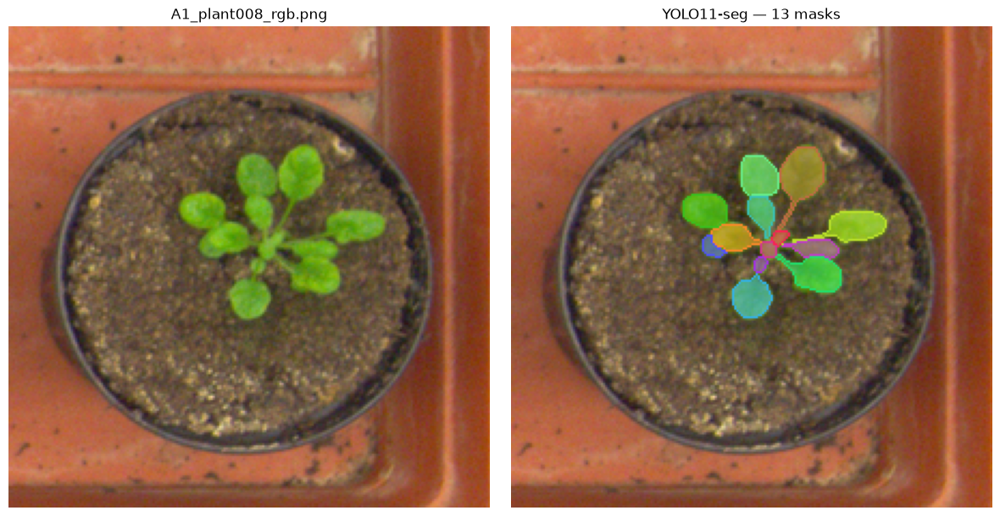

In [18]:
show_masks(all_masks[0], "YOLO11-seg")

## 4.6 Mask2Former — COCO baseline

Transformer-based universal segmentation, state of the art on CVPPP once
fine-tuned. Here it runs the COCO-instance-pretrained model (weights
auto-download) — no "leaf" class out of the box, so treat this as the baseline
and point `MODEL_NAME` at a fine-tuned checkpoint for real leaf results.

In [12]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5        # min confidence to keep an instance
MODEL_NAME = "facebook/mask2former-swin-small-coco-instance"  # swin-small fits 6 GB

In [13]:
def predict(processor, model, image):
    """Run Mask2Former on one image and return its raw outputs."""
    from PIL import Image

    inputs = processor(images=Image.fromarray(image), return_tensors="pt").to(DEVICE)
    with torch.inference_mode():
        return model(**inputs)


def extract_masks(processor, outputs, image):
    """Turn raw Mask2Former outputs into per-instance boolean masks."""
    result = processor.post_process_instance_segmentation(
        outputs, target_sizes=[image.shape[:2]], threshold=THRESHOLD
    )[0]
    seg = result["segmentation"].cpu().numpy()   # (H, W) int, -1 = no object
    return [seg == s["id"] for s in result["segments_info"]]

### Run it on the test split

In [14]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

print(f"Loading Mask2Former ({MODEL_NAME}) on {DEVICE} ...")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = Mask2FormerForUniversalSegmentation.from_pretrained(MODEL_NAME).eval().to(DEVICE)

all_masks, timings = [], [], []
for path in TEST_IMAGES:
    image = load_image(path)

    # inference
    t0 = time.perf_counter()
    outputs = predict(processor, model, image)
    t1 = time.perf_counter()

    # post processing
    masks = extract_masks(processor, outputs, image)
    t2 = time.perf_counter()

    # saving of data
    image_name = os.path.basename(path)
    timings.append((image_name, t1 - t0, t2 - t1))
    all_masks.append({"image_name": image_name, "image": image, "masks": masks})
    print(f"{image_name}: {len(masks)} instances (thr={THRESHOLD})")

out = output_dir("06_mask2former")
save_outputs(out, all_masks, "mask2former")
save_timings_csv(os.path.join(out, "timings.csv"), timings)
print("wrote ->", out)

/home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Mask2Former (facebook/mask2former-swin-small-coco-instance) on cuda ...


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 758/758 [00:00<00:00, 4691.51it/s]
[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-coco-instance
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when 

A1_plant008_rgb.png: 1 instances (thr=0.5)
A1_plant017_rgb.png: 3 instances (thr=0.5)
A1_plant024_rgb.png: 1 instances (thr=0.5)
A1_plant037_rgb.png: 2 instances (thr=0.5)
A1_plant043_rgb.png: 1 instances (thr=0.5)
A1_plant044_rgb.png: 1 instances (thr=0.5)
A1_plant047_rgb.png: 1 instances (thr=0.5)
A1_plant049_rgb.png: 3 instances (thr=0.5)
A1_plant057_rgb.png: 1 instances (thr=0.5)
A1_plant063_rgb.png: 1 instances (thr=0.5)
A1_plant065_rgb.png: 1 instances (thr=0.5)
A1_plant076_rgb.png: 1 instances (thr=0.5)
A1_plant077_rgb.png: 1 instances (thr=0.5)
A1_plant079_rgb.png: 2 instances (thr=0.5)
A1_plant080_rgb.png: 2 instances (thr=0.5)
A1_plant091_rgb.png: 1 instances (thr=0.5)
A1_plant099_rgb.png: 3 instances (thr=0.5)
A1_plant120_rgb.png: 1 instances (thr=0.5)
A1_plant121_rgb.png: 1 instances (thr=0.5)
A1_plant123_rgb.png: 1 instances (thr=0.5)
A1_plant126_rgb.png: 3 instances (thr=0.5)
A1_plant128_rgb.png: 1 instances (thr=0.5)
A1_plant133_rgb.png: 1 instances (thr=0.5)
A1_plant137

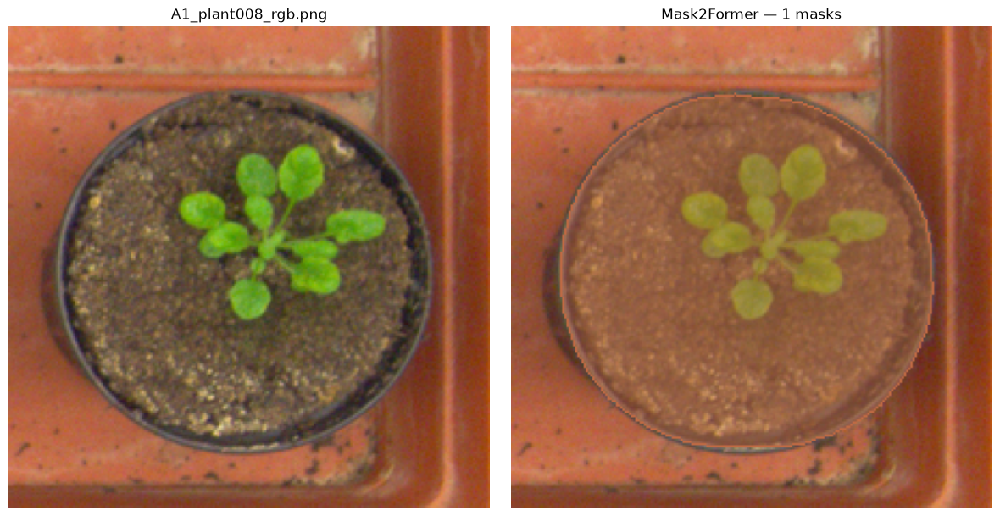

In [15]:
show_masks(all_masks[0], "Mask2Former")

# 5. Evaluation

- **DiC / |DiC|** — leaf-count bias and error (CVPPP LCC), from `counts.csv`.
- **FBD** — Dice between the predicted foreground and the GT foreground
  ("did it find the plant?")./
- **SBD** — Symmetric Best Dice, the standard CVPPP leaf-splitting number.

### Loading predicted and ground truth data

Every model wrote its results to `output_notebook/<model>/output/` with
`save_outputs()`:

```
output_notebook/01_sam2/output/
├── counts.csv              image,n_leaves  -- one row per test image
├── plant006_rgb/           one folder per test image
│   ├── plant006_rgb_sam2.png   the colour overlay (not used here)
│   ├── mask_000.png            one binary PNG per predicted leaf
│   └── mask_001.png
└── ...
```

The ground truth for the same images is already in `TEST_DATA`: the leaf count
in `n_leaves`, and the per-leaf instance map in `label_path`.

In [9]:
MODELS = ["01_sam2", "02_leaf_only_sam", "03_hq_sam",
          "04_mask_rcnn", "05_yolo_seg", "06_mask2former"]


# --- ground truth, straight from the loaded test split ----------------------
# Everything below is keyed by the image file name ("plant006_rgb.png") -- the
# same name save_outputs() wrote into each model's counts.csv, so the two sides
# join directly.
GT_COUNTS = {image: int(n_leaves)
             for image, n_leaves in zip(TEST_DATA["image"], TEST_DATA["n_leaves"])}

# load_label_image() resizes to 224 x 224, exactly like the images the models saw,
# so ground-truth and predicted masks are pixel-comparable
GT_MASKS = {image: get_masks_from_label_image(load_label_image(label_path))
            for image, label_path in zip(TEST_DATA["image"], TEST_DATA["label_path"])}


# --- every model's predictions, read once -----------------------------------
PRED_COUNTS = {}   # model name -> {image name: predicted leaf count}
PRED_MASKS = {}    # model name -> {image name: [boolean (h, w) mask, ...]}

for model_name in MODELS:
    model_dir = output_dir(model_name)
    counts_csv = os.path.join(model_dir, "counts.csv")
    if not os.path.isfile(counts_csv):
        print(f"{model_name}: not run yet -- skipped")
        continue

    counts = pd.read_csv(counts_csv)                  # image,n_leaves
    PRED_COUNTS[model_name] = {image: int(n)
                               for image, n in zip(counts["image"], counts["n_leaves"])}

    # save_outputs() put each image's masks in a folder named after it minus the
    # extension, written as 255 = leaf, 0 = background
    PRED_MASKS[model_name] = {
        image: [np.asarray(Image.open(f).convert("L")) > 127
                for f in sorted(glob.glob(os.path.join(
                    model_dir, os.path.splitext(image)[0], "mask_*.png")))]
        for image in counts["image"]}


print(f"ground truth: {len(GT_COUNTS)} images, "
      f"{sum(len(m) for m in GT_MASKS.values())} leaves in total")
for model_name, counts in PRED_COUNTS.items():
    print(f"{model_name}: {len(counts)} images, "
          f"{sum(len(m) for m in PRED_MASKS[model_name].values())} leaves predicted")

03_hq_sam: not run yet -- skipped
ground truth: 162 images, 2168 leaves in total
01_sam2: 162 images, 1095 leaves predicted
02_leaf_only_sam: 162 images, 2259 leaves predicted
04_mask_rcnn: 162 images, 2291 leaves predicted
05_yolo_seg: 162 images, 2325 leaves predicted
06_mask2former: 162 images, 278 leaves predicted


### Evaluation metrics

***Leaf Count metrics:***

| metric | formula | reads as |
|---|---|---|
| **DiC** | `mean(diff)` | counting **bias**: `+1.5` = over-counts by 1.5 leaves on average. Over- and under-counts cancel out. |
| **\|DiC\|** | `mean(abs(diff))` | counting **error size**. Nothing cancels, so `\|DiC\| >= \|DiC\|`. |
| **MSE** | `mean(diff ** 2)` | same, squared -- punishes the badly wrong images. |
| **%agree** | `100 * mean(diff == 0)` | share of images counted *exactly* right. |


***Leaf segmentation quality metrics***

```
Dice(A, B) = 2 * |A and B| / (|A| + |B|)          1.0 = identical, 0.0 = disjoint
```

| metric | formula | reads as |
|---|---|---|
| **FBD** | `Dice(union of all predicted leaves, union of all GT leaves)` | *"did it find the plant?"* -- merges every leaf into one foreground blob first, so how the plant was split into individual leaves makes no difference. |
| **SBD** | `min(BD(gt -> pred), BD(pred -> gt))` | *"did it split the plant into the right leaves?"* -- the standard CVPPP leaf-segmentation score. |

where **BD** (Best Dice) matches each leaf with its single best partner on the
other side and averages those best scores:

```
BD(gt -> pred) = mean over GT leaves    of ( best Dice to any predicted leaf )
BD(pred -> gt) = mean over pred leaves  of ( best Dice to any GT leaf )
```

In [10]:
def dice(a, b):
    """Dice overlap of two boolean masks: 2 * |A and B| / (|A| + |B|)."""
    total = a.sum() + b.sum()
    if total == 0:
        return 1.0                      # two empty masks agree perfectly
    return 2.0 * np.logical_and(a, b).sum() / total


def mask_union(masks, shape):
    """Every mask merged into a single foreground mask (no masks -> all background)."""
    merged = np.zeros(shape, dtype=bool)
    for mask in masks:
        merged |= mask
    return merged


def foreground_dice(pred_masks, gt_masks):
    """FBD -- plant-vs-background quality, ignoring how the plant was split up."""
    shape = gt_masks[0].shape
    return dice(mask_union(pred_masks, shape), mask_union(gt_masks, shape))


def symmetric_best_dice(pred_masks, gt_masks):
    """SBD -- leaf-splitting quality: the worse of the two Best-Dice directions."""
    if not pred_masks and not gt_masks:
        return 1.0                      # nothing to find, nothing predicted
    if not pred_masks or not gt_masks:
        return 0.0                      # missed everything, or invented leaves

    # d[i][j] = overlap between GT leaf i and predicted leaf j
    d = np.array([[dice(gt, pred) for pred in pred_masks] for gt in gt_masks])

    best_for_each_gt = d.max(axis=1)     # each GT leaf's best prediction
    best_for_each_pred = d.max(axis=0)   # each prediction's best GT leaf
    return min(best_for_each_gt.mean(), best_for_each_pred.mean())

### Evaluate

`score_per_image()` builds one row per test image holding the raw ingredients of
every metric; the summary is then literally the column means of that table, so
any number in the results can be traced back to the images that produced it.

In [11]:
PER_IMAGE_SCORES = {}    # model name -> its full per-image table, for drilling in
summary_rows = []

for model_name, pred_counts in PRED_COUNTS.items():   # models that were run
    pred_masks = PRED_MASKS[model_name]

    # --- one row per test image, holding the raw ingredients of every metric --
    rows = []
    for image_name, gt_count in sorted(GT_COUNTS.items()):
        if image_name not in pred_counts:      # model has no output for this image
            continue

        rows.append({
            "image": image_name,
            "gt": gt_count,
            "pred": pred_counts[image_name],
            "diff": pred_counts[image_name] - gt_count,          # + = over-counted
            "FBD": foreground_dice(pred_masks[image_name], GT_MASKS[image_name]),
            "SBD": symmetric_best_dice(pred_masks[image_name], GT_MASKS[image_name]),
        })

    per_image = pd.DataFrame(rows)
    if per_image.empty:
        print(f"{model_name}: no images matched the ground truth -- skipped")
        continue

    PER_IMAGE_SCORES[model_name] = per_image

    # --- the six CVPPP numbers -- every one an average down that table --------
    diff = per_image["diff"]
    summary_rows.append({
        "model": model_name,
        "n": len(per_image),
        "DiC": diff.mean(),                        # signed  -> over/under-counting bias
        "|DiC|": diff.abs().mean(),                # unsigned -> error size
        "MSE": (diff ** 2).mean(),
        "%agree": 100.0 * (diff == 0).mean(),      # counted exactly right
        "FBD": per_image["FBD"].mean(),
        "SBD": per_image["SBD"].mean(),
    })

RESULTS = pd.DataFrame(summary_rows).set_index("model")
RESULTS.round(3)


,n,DiC,|DiC|,MSE,%agree,FBD,SBD
model,,,,,,,
01_sam2,162,-6.623,6.623,55.623,1.235,0.778,0.446
02_leaf_only_sam,162,0.562,7.426,84.043,6.173,0.615,0.365
04_mask_rcnn,162,0.475,0.920,1.920,41.975,0.947,0.833
05_yolo_seg,162,0.969,1.364,3.623,29.630,0.956,0.844
06_mask2former,162,-11.667,11.667,167.309,0.000,0.249,0.023


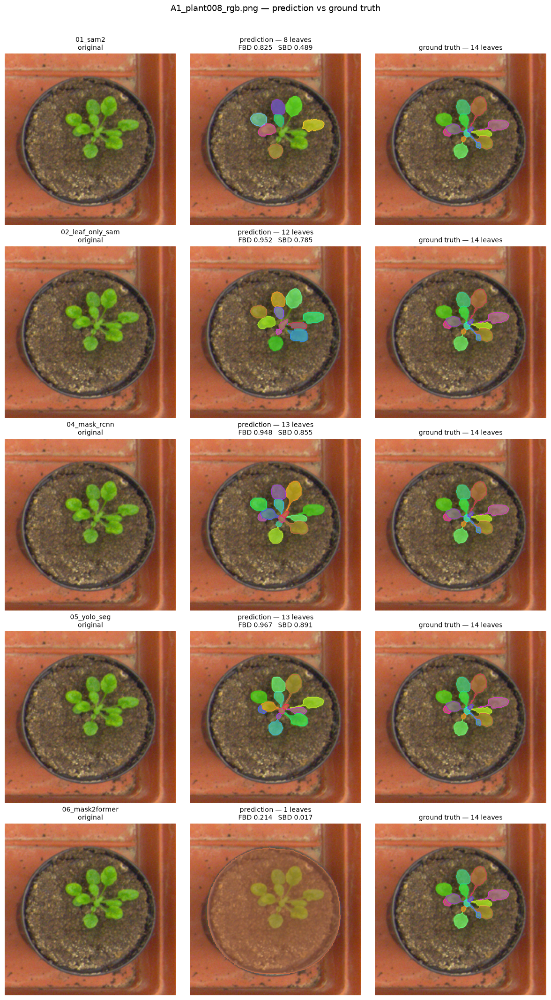

In [15]:
# --- one image, every model side by side ------------------------------------
TARGET = "A1_plant008_rgb.png"

image = load_image(TEST_DATA.loc[TEST_DATA["image"] == TARGET, "image_path"].iloc[0])
gt_masks = GT_MASKS[TARGET]

# only the models that actually produced this image (03_hq_sam has no output yet)
models = [name for name in PRED_MASKS if TARGET in PRED_MASKS[name]]

TITLE_IN = 0.7                                  # inches reserved for the figure title
fig_h = 4.2 * len(models) + TITLE_IN
fig, axes = plt.subplots(len(models), 3, figsize=(12, fig_h), squeeze=False)

for (ax_orig, ax_pred, ax_gt), model_name in zip(axes, models):
    pred_masks = PRED_MASKS[model_name][TARGET]

    ax_orig.imshow(image)
    ax_orig.set_title(f"{model_name}\noriginal", fontsize=10)

    ax_pred.imshow(overlay_masks(image, pred_masks))
    ax_pred.set_title(f"prediction — {len(pred_masks)} leaves\n"
                      f"FBD {foreground_dice(pred_masks, gt_masks):.3f}   "
                      f"SBD {symmetric_best_dice(pred_masks, gt_masks):.3f}", fontsize=10)

    ax_gt.imshow(overlay_masks(image, gt_masks))
    ax_gt.set_title(f"ground truth — {len(gt_masks)} leaves", fontsize=10)

    for ax in (ax_orig, ax_pred, ax_gt):
        ax.axis("off")

fig.suptitle(f"{TARGET} — prediction vs ground truth", fontsize=13)
# leave the top TITLE_IN inches to the suptitle; h_pad keeps the 2-line row titles clear
fig.tight_layout(rect=(0, 0, 1, 1 - TITLE_IN / fig_h), h_pad=1.5)
plt.show()


In [17]:
# --- how fast is each model? straight from the timings.csv each run wrote ----
speed_rows = []

for model_name in MODELS:
    timings_csv = os.path.join(output_dir(model_name), "timings.csv")
    if not os.path.isfile(timings_csv):
        print(f"{model_name}: no timings.csv -- skipped")
        continue

    timings = pd.read_csv(timings_csv)                   # image,inference_s,postprocess_s
    total = timings["inference_s"] + timings["postprocess_s"]
    speed_rows.append({
        "model": model_name,
        "n": len(timings),
        "inference_s": timings["inference_s"].mean(),       # forward pass, warm-up included
        "inference_med_s": timings["inference_s"].median(), # steady state, warm-up excluded
        "postproc_s": timings["postprocess_s"].mean(),      # mask filtering / resizing
        "total_s": total.mean(),
    })

SPEED = pd.DataFrame(speed_rows).set_index("model")
SPEED.round(4)


03_hq_sam: no timings.csv -- skipped


,n,inference_s,inference_med_s,postproc_s,total_s
model,,,,,
01_sam2,162,3.7500,3.743,0.0018,3.7518
02_leaf_only_sam,162,8.7956,8.791,0.0165,8.8121
04_mask_rcnn,162,0.0641,0.063,0.0009,0.0650
05_yolo_seg,162,0.0074,0.007,0.0168,0.0242
06_mask2former,162,0.0455,0.043,0.0127,0.0582


# 6. Final Model and conclusion

The segmenter is a preprocessing stage: it turns one plant photo into N per-leaf crops that a disease classifier consumes. That fixes which metrics carry weight:

FBD and SBD are the product metrics. They decide whether a crop contains one clean leaf or a leaf plus soil, pot rim, and half of its neighbour. Whatever background a mask lets through becomes input noise the classifier has to learn to ignore.
The direction of count error matters more than its size. Under-counting silently discards leaves — lost training samples and missed diagnoses, unrecoverable downstream. Over-counting emits an extra fragment, which is cheap to filter by area or aspect ratio. %agree itself buys nothing here, because leaf count is not a reported output of this pipeline.
Throughput is a first-class cost, since this runs over the whole corpus and re-runs every time the pipeline is retuned.

***06_mask2former*** — unusable as configured. SBD 0.023, FBD 0.249, one mask covering the entire pot. It yields no per-leaf crops at all, so nothing downstream can use it. DiC = -|DiC| = -11.667 confirms it under-counts on all 162 images. Fine-tuning it would likely fix this, but that is another training run to reach a starting line the other two fine-tuned models have already passed.

***01_sam2*** — finds the plant, loses half the leaves. FBD 0.778 says the plant is located; SBD 0.446 and DiC = -|DiC| = -6.623 say it never over-counts on a single image, dropping ~6.6 leaves per plant. The masks it does keep are decent — the failure is the post-hoc filter (MIN_AREA / MAX_AREA / MIN_GREEN) deleting real leaves. That's tuneable, but it fails in exactly the direction this pipeline cannot afford, and at 3.75 s/image it is 156× slower than YOLO. Its one genuine advantage: no labels required.

***02_leaf_only_sam*** — worst cost-for-quality on the table. FBD 0.615 and SBD 0.365 are the weakest of the five that produce leaf-shaped output, and it is the slowest model tested at 8.81 s/image. Its DiC of +0.562 looks like the best count bias in the table and is an artifact: |DiC| = 7.426, MSE = 84.0. The filters simultaneously delete real leaves and admit junk, and the two errors cancel in the mean. Crops from this model would be the noisiest input the classifier receives.

***04_mask_rcnn*** — the real competitor. SBD 0.833, FBD 0.947, and the best counting in the table (|DiC| 0.920, MSE 1.920, 42.0 % exact). Genuinely deployable. Its cost is 169 MB of weights and 0.065 s/image.

***05_yolo_seg*** — best masks, cheapest to run. SBD 0.844 and FBD 0.956 are the highest of all six, at 0.024 s/image and 5.8 MB.

**Why YOLO11-seg over the rest?**
1. It produces the cleanest crops. Best SBD and best FBD in the table. FBD 0.956 means roughly 4 % of the pixels in a crop are on the wrong side of the leaf boundary, against 5 % for Mask R-CNN, 22 % for SAM 2, and 39 % for Leaf Only SAM. That contamination is precisely what the classifier inherits.

2. Its edge over Mask R-CNN is real, not noise. Paired across the same 162 images: +0.0117 SBD, 95 % CI [+0.005, +0.018], better on 111 of 162 images, p < 0.0001. Small — but it means picking YOLO costs nothing in mask quality, which is what frees the decision to turn on cost.

3. Its one weakness is the harmless kind of error. YOLO's counting is worse than Mask R-CNN's (|DiC| 1.364 vs 0.920, 29.6 % vs 42.0 % exact), but DiC = +0.969 shows the errors are over-counts: it splits a leaf into two crops rather than dropping it. A spurious fragment is filterable; a missing leaf is lost data. Compare SAM 2's −6.623, which is the same magnitude of error pointing the fatal way. So Mask R-CNN's counting advantage buys accuracy in a number this pipeline never reports, while YOLO's deficit costs a few discardable crops.

4. It deploys where the others can't. At 5.8 MB it runs on CPU or edge hardware — 29× smaller than Mask R-CNN and 62× smaller than the SAM ViT-B checkpoint — with a lighter dependency stack than the segment_anything / transformers paths.

**Conclusion**

adopt 05_yolo_seg as the leaf segmenter feeding the disease classifier. It has the best mask quality of every model tested, its only metric deficit falls on a number this pipeline doesn't consume and errs in the recoverable direction, and it is 2.7× faster and 29× smaller than the nearest competitor. Keep 04_mask_rcnn as the documented fallback if leaf count later becomes a reported output. The price of this choice is that YOLO needs labelled data and a fine-tune, which SAM 2 does not — so if the olive dataset turns out to be unlabelled, SAM 2 with a re-tuned area filter is the zero-label fallback.

One thing still outstanding before this is a committed decision: both fine-tuned models were trained and scored on CVPPP arabidopsis rosettes, and neither has seen an olive leaf. The ranking should be re-confirmed on a sample of target-domain images.